In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [2]:
# Load the CSV file into a DataFrame
df = pd.read_csv('../../plotting/results/All_data - main.csv')
df.head()

,cation,anion,solvent,temperature,solute concentration,length of traj up to now,353K student cation diffusivity,323K student cation diffusivity,293K student cation diffusivity,323K per salt student cation diffusivity,...,exp anion diffusivity,353K student solvent diffusivity,323K student solvent diffusivity,293K student solvent diffusivity,323K per salt student solvent diffusivity,OPLS student solvent diffusivity,exp solvent diffusivity,353K_stability,323K_stability,293K_stability
0,Na,OTf,PC,298K,0.1M,20ns,5.300000e-01,1.30,1.18,NaN,...,3.70,3.090000e+00,3.32,2.65,NaN,NaN,4.92,stable,stable,stable
1,Na,OTf,DEGDME,298K,0.1M,20ns,NaN,NaN,7.24,NaN,...,5.44,NaN,NaN,11.01,NaN,NaN,11.60,stable,stable,stable
2,Na,PF6,PC,298K,0.1M,20ns,1.050000e+00,NaN,0.85,NaN,...,4.29,3.660000e+00,3.00,3.10,NaN,NaN,4.97,stable,stable,stable
3,Na,PF6,DEGDME,298K,0.1M,20ns,1.277091e+09,7.98,5.47,NaN,...,5.55,4.817527e+09,14.23,12.45,NaN,NaN,11.80,unstable,stable,stable
4,Na,OTf,TGDME,298K,0.1M,20ns,NaN,70851.00,1.18,NaN,...,1.77,NaN,14122.00,1.92,NaN,NaN,3.05,stable,unstable,stable


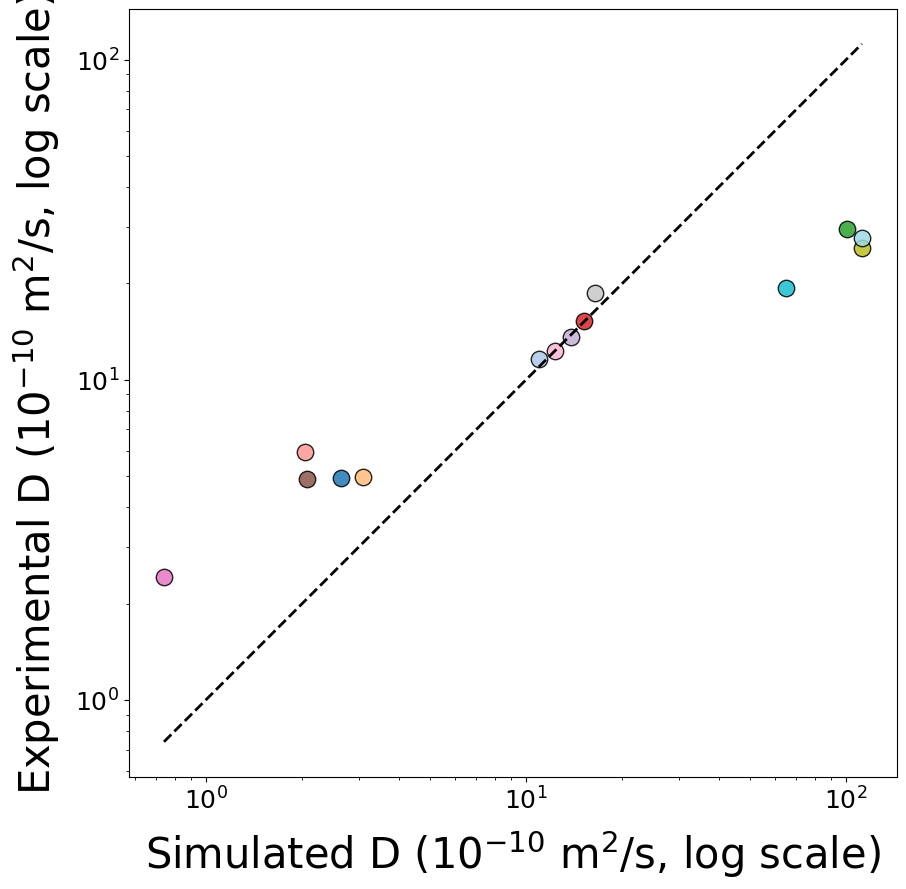

In [8]:
# Helper to create R2 parity log-log plots for 293K solvent only -- REWRITTEN for clarity, speed, and deprecation warning removal, NO LEGEND, NO TITLE
def plot_r2_unique_colors(ax, x, y, labels, title, colormap_name='tab20'):
    # import matplotlib
    # import numpy as np

    # Filter out any non-positive values to avoid log10 errors
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    labels = np.array([str(l) for l in labels])
    nonzero_mask = (x > 0) & (y > 0)
    if not np.any(nonzero_mask):
        return [], []
    x, y, labels = x[nonzero_mask], y[nonzero_mask], labels[nonzero_mask]

    num_points = len(x)
    # Use modern colormap API to avoid deprecation
    if hasattr(matplotlib, 'colormaps'):
        cmap = matplotlib.colormaps[colormap_name]
        colors = [cmap(i / max(num_points-1, 1)) for i in range(num_points)]
    else:
        cmap = matplotlib.cm.get_cmap(colormap_name, num_points)
        colors = [cmap(i) for i in range(num_points)]

    # Scatter each point
    for xi, yi, color in zip(x, y, colors):
        ax.scatter([xi], [yi], alpha=0.85, color=[color], s=140, edgecolor='k', linewidth=1.0)  # larger marker

    # Plot parity line (y=x) on log-log axes
    min_val, max_val = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)  # thicker line

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Simulated D ($10^{-10}$ m$^2$/s, log scale)', fontsize=30, labelpad=10)
    ax.set_ylabel('Experimental D ($10^{-10}$ m$^2$/s, log scale)', fontsize=30, labelpad=10)
    # No title!

    # R^2 for log-log
    # if len(x) > 1:
    #     logx = np.log10(x)
    #     logy = np.log10(y)
    #     corr = np.corrcoef(logx, logy)[0, 1]
    #     r2 = corr ** 2
    #     ax.text(
    #         0.03, 0.92, 
    #         f"$R^2_{{\\log}}$ = {r2:.2f}",
    #         transform=ax.transAxes,
    #         fontsize=22,
    #         bbox=dict(facecolor='white', alpha=0.54, edgecolor='none')
    #     )
    ax.set_aspect('equal', adjustable='box')

    # Increase tick font sizes
    ax.tick_params(axis='both', labelsize=18)

    # No legend handles returned
    return [], []

# --------- Prepare data: only 293K solvent, sim vs exp, log-log ----------
exp_column = 'exp solvent diffusivity'
sim_column = '293K student solvent diffusivity'
stability_cols = ['353K_stability', '323K_stability', '293K_stability']

# No exclusion for concentrations on solvent type
exclude = pd.Series([False] * len(df))

mask = (
    (~exclude) &
    df[sim_column].notnull() &
    df[exp_column].notnull()
)

# All stability columns must be 'stable'
stability_mask = np.logical_and.reduce([
    df[col].astype(str).str.lower() == 'stable' for col in stability_cols
])
combined_mask = mask & stability_mask

xvals = df.loc[combined_mask, sim_column].astype(float).values
yvals = df.loc[combined_mask, exp_column].astype(float).values
lbls = df.loc[combined_mask, ['cation', 'anion', 'solvent', 'temperature', 'solute concentration']].astype(str).agg('-'.join, axis=1).values.tolist()
# No title:
# title = "Solvent D: 293K Student vs Exp [log-log]"

# ----------- Plot this single plot -----------
fig, ax = plt.subplots(figsize=(11, 9))
plot_r2_unique_colors(ax, xvals, yvals, lbls, title=None)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1284259/78212407.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap_name, num_points)


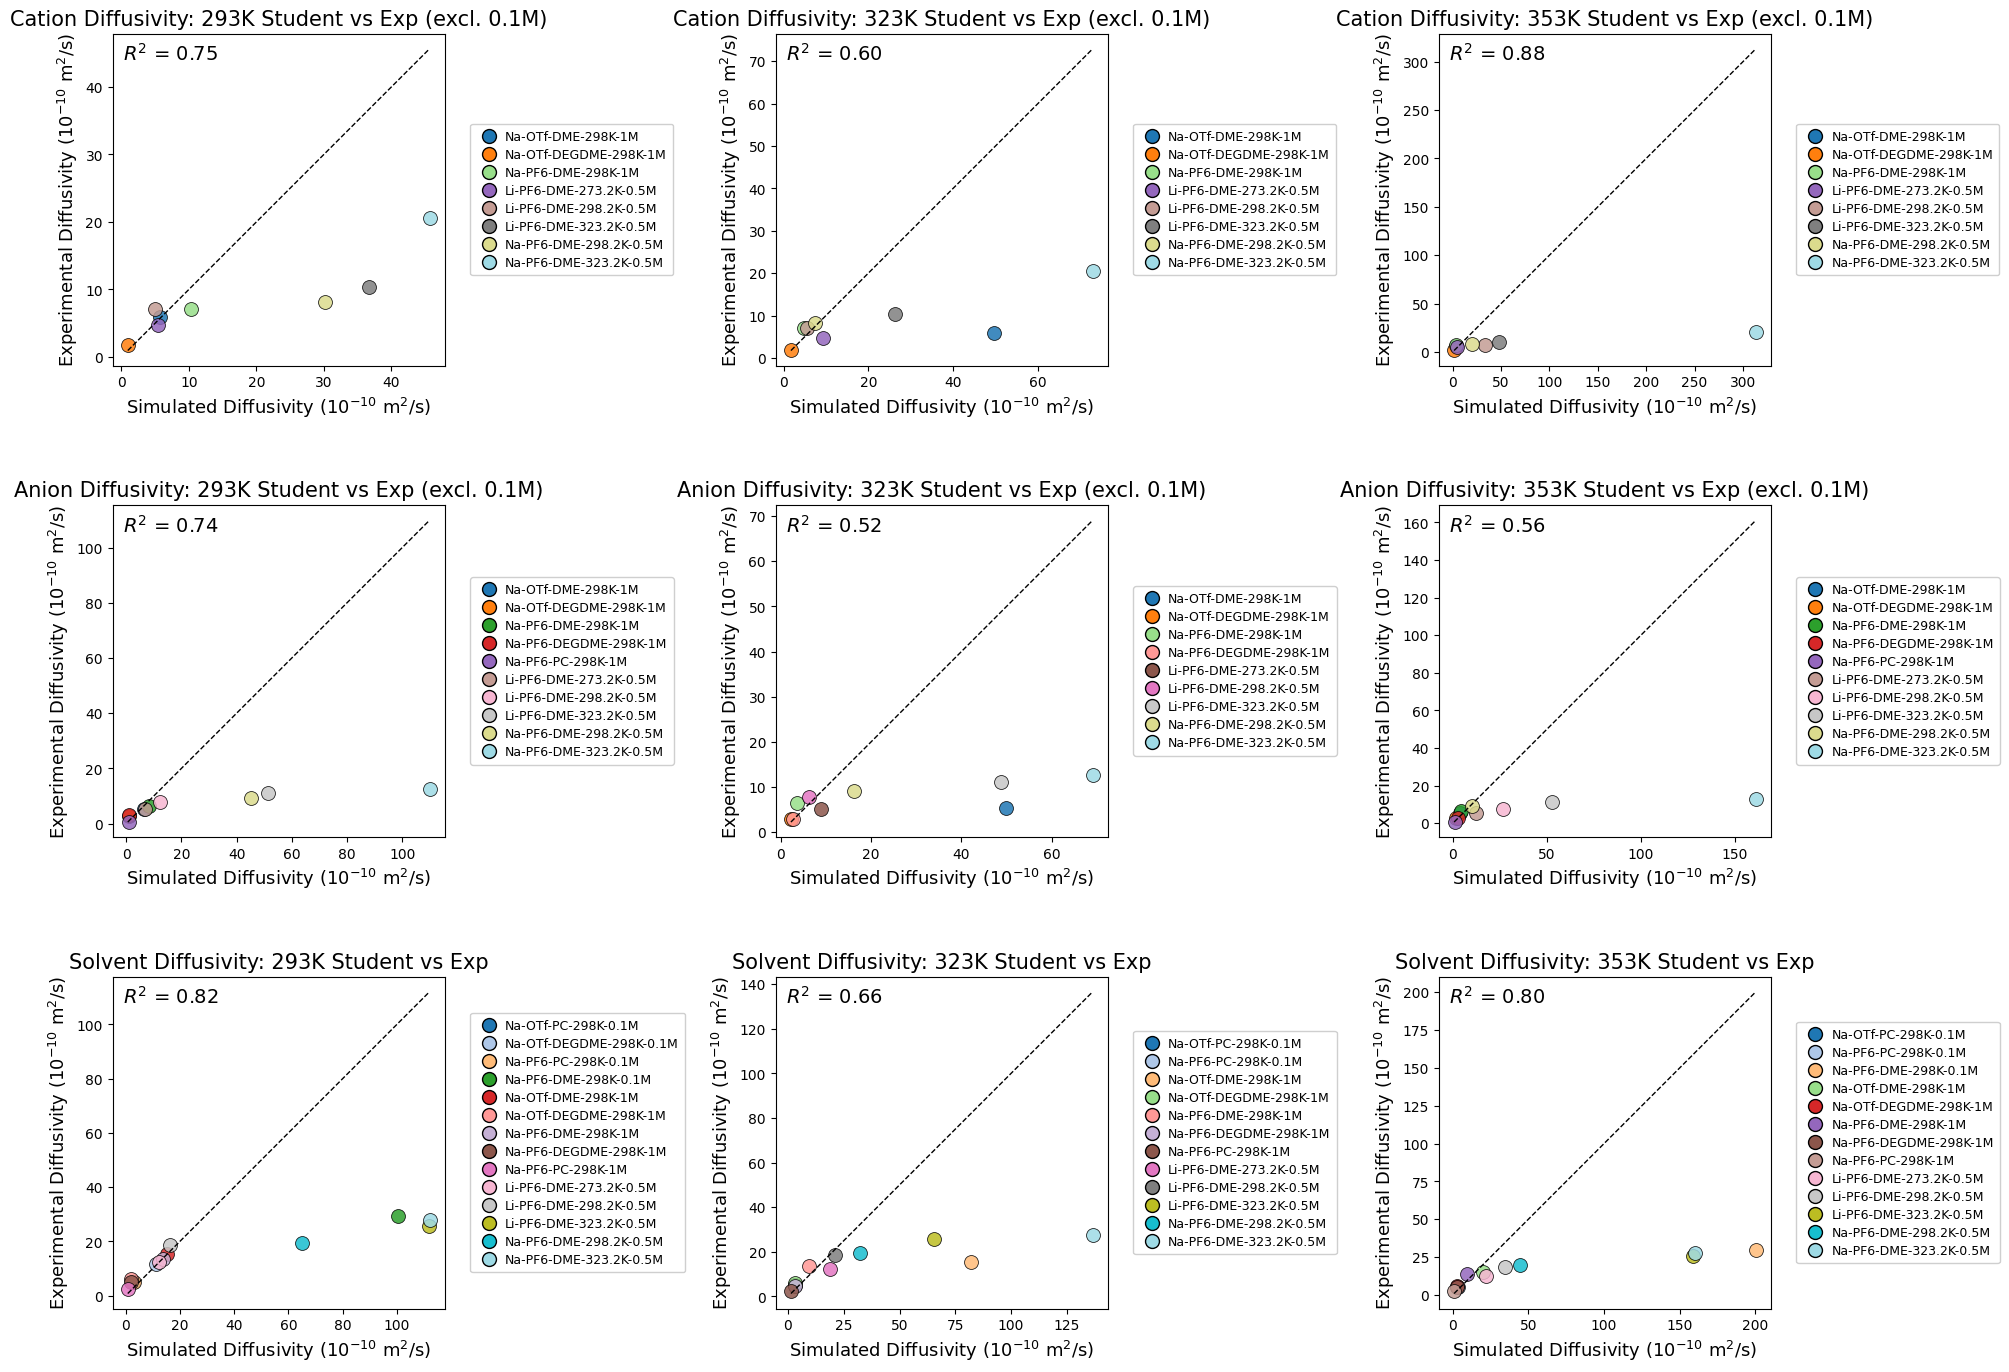

In [3]:
# Helper to create R2 parity plots for each type/temperature
def plot_r2_unique_colors(ax, x, y, labels, title, colormap_name='tab20'):
    import matplotlib.cm as cm
    from matplotlib.lines import Line2D

    num_points = len(x)
    cmap = cm.get_cmap(colormap_name, num_points)
    colors = [cmap(i) for i in range(num_points)]

    handle_objs = []
    for i, (xi, yi, label) in enumerate(zip(x, y, labels)):
        handle = ax.scatter([xi], [yi], alpha=0.85, color=[colors[i]], label=str(label), s=100, edgecolor='k', linewidth=0.6)
        handle_objs.append(handle)

    min_val = min(min(x), min(y))
    max_val = max(max(x), max(y))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
    ax.set_xlabel('Simulated Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_ylabel('Experimental Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_title(title, fontsize=15)

    # R^2
    if len(x) > 1:
        correlation_matrix = np.corrcoef(x, y)
        r2 = correlation_matrix[0, 1] ** 2
        ax.text(0.03, 0.92, f"$R^2$ = {r2:.2f}", transform=ax.transAxes, fontsize=14,
                bbox=dict(facecolor='white', alpha=0.54, edgecolor='none'))
    ax.set_aspect('equal', adjustable='box')

    # Always convert all labels to string at this point to ensure they're not arrays
    labels_str = [str(lab) for lab in labels]
    legend_handles = []
    for lab, col in zip(labels_str, colors):
        legend_handles.append(
            Line2D([0],[0], marker='o', color='w', markerfacecolor=col, markeredgecolor='k', markersize=10, label=lab)
        )
    return legend_handles, labels_str

# --------- Prepare data: 9 plots, each for cation/anion/solvent and each for 293K/323K/353K (sim vs exp) ----------
diff_types = ['cation', 'anion', 'solvent']
temps = ['293K', '323K', '353K']
exp_columns = {
    'cation':   'exp student cation diffusivity',
    'anion':    'exp anion diffusivity',
    'solvent':  'exp solvent diffusivity',
}
sim_columns = {
    'cation': {
        '293K': '293K student cation diffusivity',
        '323K': '323K student cation diffusivity',
        '353K': '353K student cation diffusivity',
    },
    'anion': {
        '293K': '293K student anion diffusivity',
        '323K': '323K student anion diffusivity',
        '353K': '353K student anion diffusivity',
    },
    'solvent': {
        '293K': '293K student solvent diffusivity',
        '323K': '323K student solvent diffusivity',
        '353K': '353K student solvent diffusivity',
    },
}

# --------- Stability columns ---------
stability_cols = ['353K_stability', '323K_stability', '293K_stability']

# Prepare 9 sets of (x, y, labels, title) for the 9 plots
plot_data = []

for dt in diff_types:
    for tk in temps:
        # for cation/anion, for 293K and 323K exclude 0.1M (like reference)
        # for solvent, do not exclude 0.1M
        if dt in ['cation', 'anion']:
            exclude = (df['solute concentration'] == '0.1M')
        else:
            exclude = pd.Series([False] * len(df))
        # Create mask for non-excluded & notnull points
        mask = (
            (~exclude) &
            df[sim_columns[dt][tk]].notnull() &
            df[exp_columns[dt]].notnull()
        )
        # Additionally require all stability columns are 'stable'
        stability_mask = (
            (df[stability_cols[0]].astype(str).str.lower() == 'stable') &
            (df[stability_cols[1]].astype(str).str.lower() == 'stable') &
            (df[stability_cols[2]].astype(str).str.lower() == 'stable')
        )
        combined_mask = mask & stability_mask
        xvals = df.loc[combined_mask, sim_columns[dt][tk]].astype(float).values
        yvals = df.loc[combined_mask, exp_columns[dt]].astype(float).values
        lbls = df.loc[combined_mask, ['cation', 'anion', 'solvent', 'temperature', 'solute concentration']].astype(str).agg('-'.join, axis=1).values

        # Ensure labels is 1D list of str
        lbls = [str(l) for l in lbls]
        title = f"{dt.capitalize()} Diffusivity: {tk} Student vs Exp" + ("" if dt == "solvent" else " (excl. 0.1M)")
        plot_data.append( (xvals, yvals, lbls, title) )

# ----------- Plot all 9 in a 3x3 grid -----------

fig, axes = plt.subplots(3,3, figsize=(20, 15))
plt.subplots_adjust(left=0.07, right=0.97, bottom=0.08, top=0.93, hspace=0.42, wspace=0.40)

for idx, (x, y, labels, title) in enumerate(plot_data):
    i, j = divmod(idx, 3)
    ax = axes[i][j]
    legend_handles, legend_labels = plot_r2_unique_colors(ax, x, y, labels, title)
    # Place the legend next to its own plot (on the right side)
    # NOTE: legend_labels is guaranteed to be 1D list of str, legend_handles is 1D list of Line2D
    ax.legend(handles=legend_handles, labels=legend_labels, loc='center left',
              bbox_to_anchor=(1.05, 0.5), fontsize=9, framealpha=0.94, borderaxespad=0.7,
              ncol=1, labelspacing=0.4, handletextpad=0.3, borderpad=0.5, markerscale=1.0)

plt.show()

/tmp/ipykernel_1284259/3772237911.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap_name, num_points)


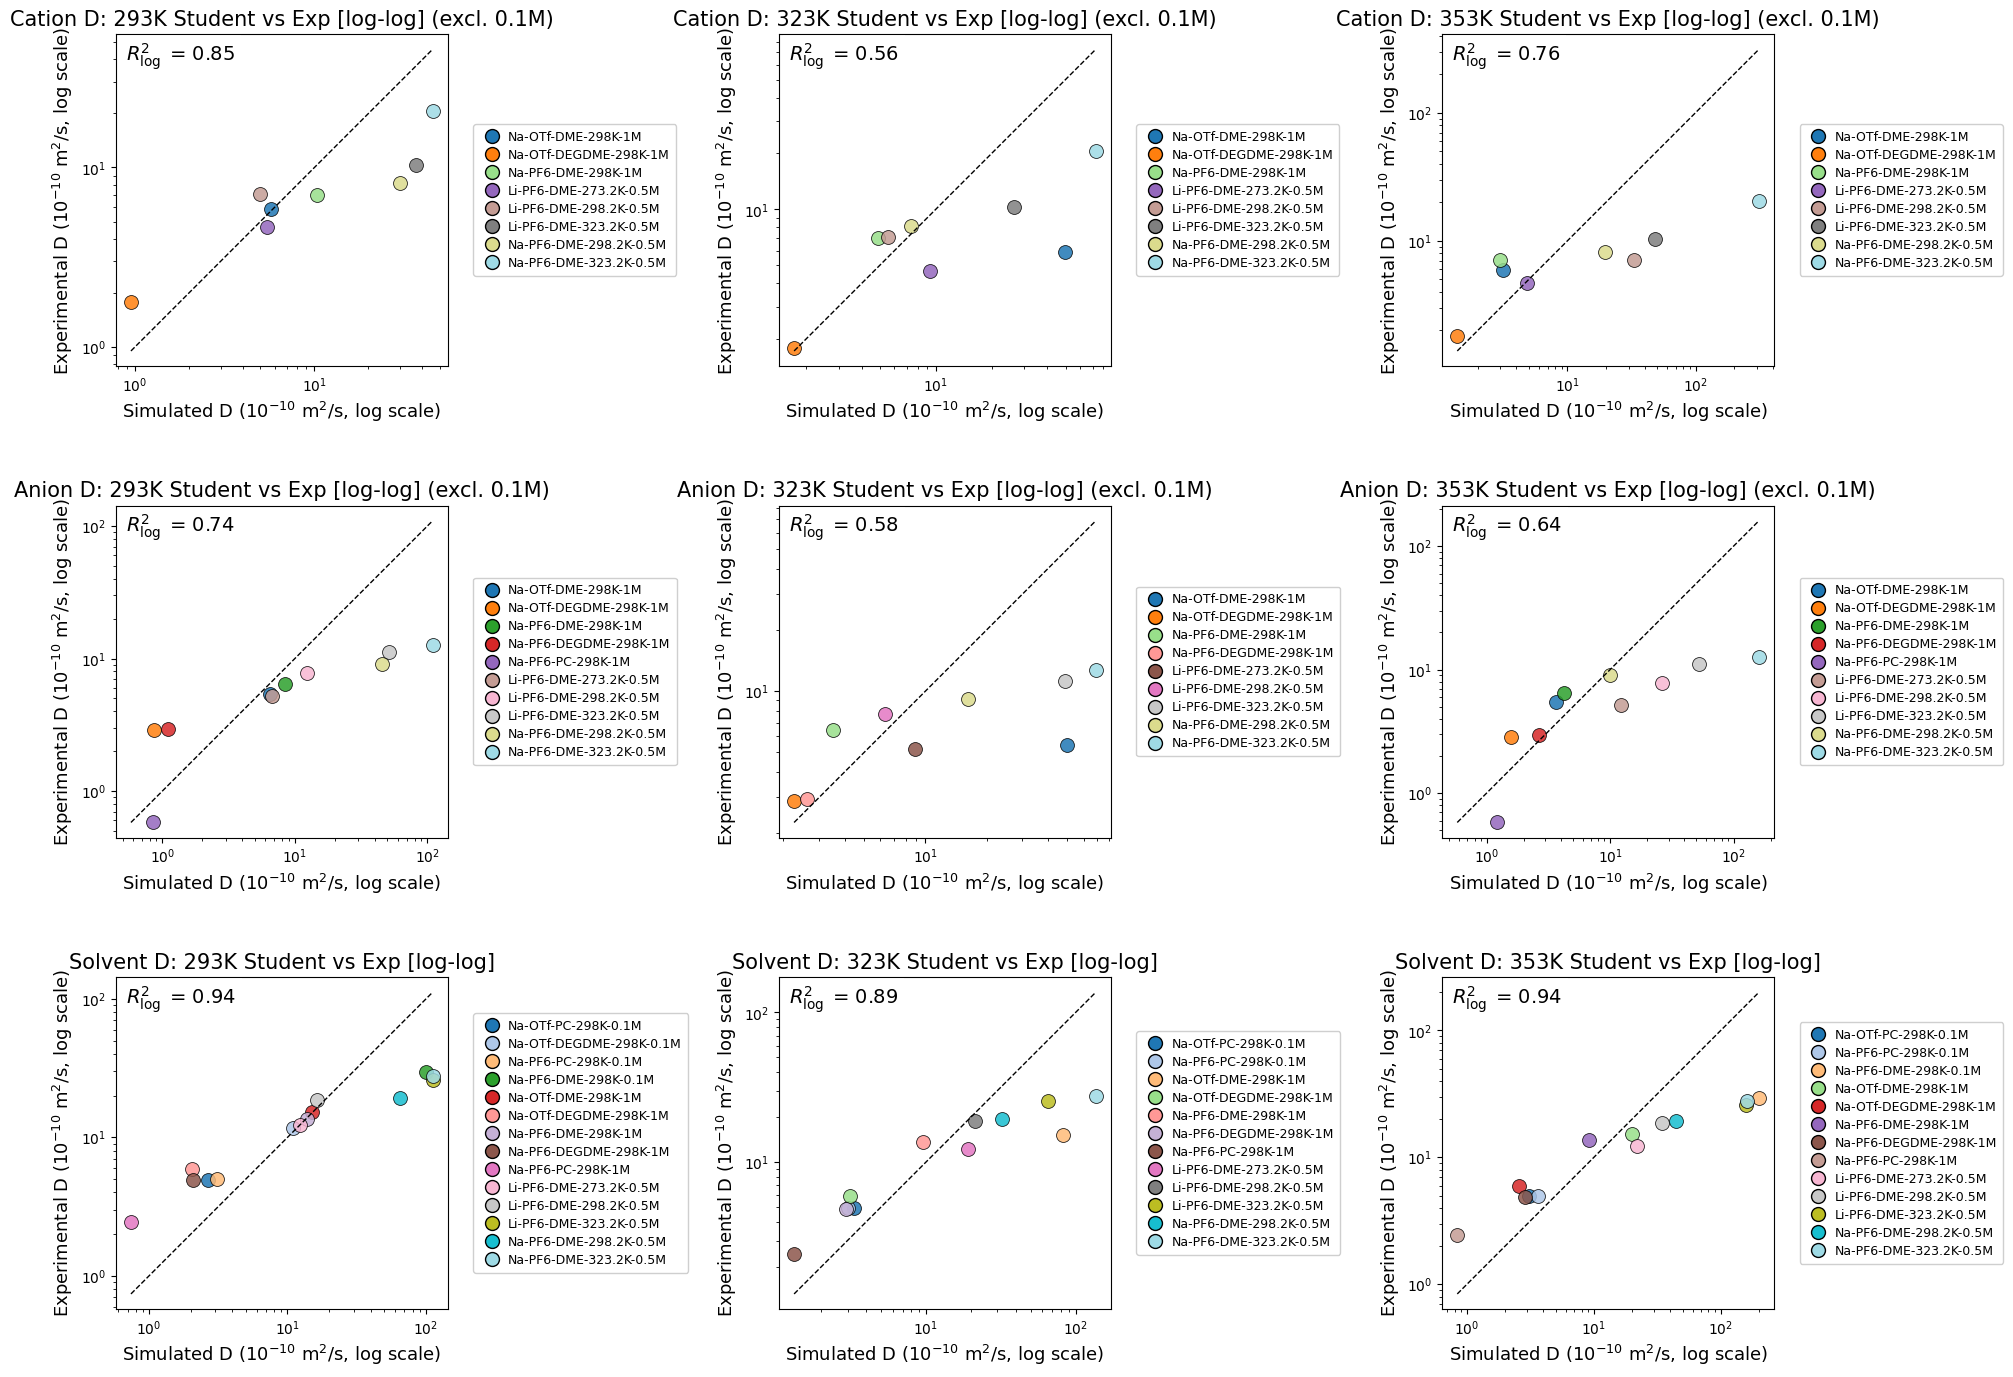

In [4]:
# Helper to create R2 parity log-log plots for each type/temperature
def plot_r2_unique_colors(ax, x, y, labels, title, colormap_name='tab20'):
    import matplotlib.cm as cm
    from matplotlib.lines import Line2D
    import numpy as np

    # Filter out any non-positive values to avoid errors in log-log plot
    x = np.array(x)
    y = np.array(y)
    nonzero_mask = (x > 0) & (y > 0)
    x = x[nonzero_mask]
    y = y[nonzero_mask]
    filtered_labels = [str(labels[i]) for i in range(len(labels)) if nonzero_mask[i]]

    num_points = len(x)
    cmap = cm.get_cmap(colormap_name, num_points)
    colors = [cmap(i) for i in range(num_points)]

    handle_objs = []
    for i, (xi, yi, label) in enumerate(zip(x, y, filtered_labels)):
        handle = ax.scatter([xi], [yi], alpha=0.85, color=[colors[i]], label=str(label), s=100, edgecolor='k', linewidth=0.6)
        handle_objs.append(handle)

    # Plot parity line on log-log
    min_val = min(min(x), min(y))
    max_val = max(max(x), max(y))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Simulated D ($10^{-10}$ m$^2$/s, log scale)', fontsize=13)
    ax.set_ylabel('Experimental D ($10^{-10}$ m$^2$/s, log scale)', fontsize=13)
    ax.set_title(title, fontsize=15)

    # R^2 on log-log data
    if len(x) > 1:
        logx = np.log10(x)
        logy = np.log10(y)
        correlation_matrix = np.corrcoef(logx, logy)
        r2 = correlation_matrix[0, 1] ** 2
        ax.text(0.03, 0.92, f"$R^2_{{\\log}}$ = {r2:.2f}", transform=ax.transAxes, fontsize=14,
                bbox=dict(facecolor='white', alpha=0.54, edgecolor='none'))
    ax.set_aspect('equal', adjustable='box')

    # Always convert all labels to string at this point to ensure they're not arrays
    legend_handles = []
    for lab, col in zip(filtered_labels, colors):
        legend_handles.append(
            Line2D([0],[0], marker='o', color='w', markerfacecolor=col, markeredgecolor='k', markersize=10, label=lab)
        )
    return legend_handles, filtered_labels

# --------- Prepare data: 9 plots, each for cation/anion/solvent and each for 293K/323K/353K (sim vs exp) ----------
diff_types = ['cation', 'anion', 'solvent']
temps = ['293K', '323K', '353K']
exp_columns = {
    'cation':   'exp student cation diffusivity',
    'anion':    'exp anion diffusivity',
    'solvent':  'exp solvent diffusivity',
}
sim_columns = {
    'cation': {
        '293K': '293K student cation diffusivity',
        '323K': '323K student cation diffusivity',
        '353K': '353K student cation diffusivity',
    },
    'anion': {
        '293K': '293K student anion diffusivity',
        '323K': '323K student anion diffusivity',
        '353K': '353K student anion diffusivity',
    },
    'solvent': {
        '293K': '293K student solvent diffusivity',
        '323K': '323K student solvent diffusivity',
        '353K': '353K student solvent diffusivity',
    },
}

# --------- Stability columns ---------
stability_cols = ['353K_stability', '323K_stability', '293K_stability']

# Prepare 9 sets of (x, y, labels, title) for the 9 plots
plot_data = []

for dt in diff_types:
    for tk in temps:
        # for cation/anion, for 293K and 323K exclude 0.1M (like reference)
        # for solvent, do not exclude 0.1M
        if dt in ['cation', 'anion']:
            exclude = (df['solute concentration'] == '0.1M')
        else:
            exclude = pd.Series([False] * len(df))
        # Create mask for non-excluded & notnull points
        mask = (
            (~exclude) &
            df[sim_columns[dt][tk]].notnull() &
            df[exp_columns[dt]].notnull()
        )
        # Additionally require all stability columns are 'stable'
        stability_mask = (
            (df[stability_cols[0]].astype(str).str.lower() == 'stable') &
            (df[stability_cols[1]].astype(str).str.lower() == 'stable') &
            (df[stability_cols[2]].astype(str).str.lower() == 'stable')
        )
        combined_mask = mask & stability_mask
        xvals = df.loc[combined_mask, sim_columns[dt][tk]].astype(float).values
        yvals = df.loc[combined_mask, exp_columns[dt]].astype(float).values
        lbls = df.loc[combined_mask, ['cation', 'anion', 'solvent', 'temperature', 'solute concentration']].astype(str).agg('-'.join, axis=1).values

        # Ensure labels is 1D list of str
        lbls = [str(l) for l in lbls]
        title = f"{dt.capitalize()} D: {tk} Student vs Exp [log-log]" + ("" if dt == "solvent" else " (excl. 0.1M)")
        plot_data.append( (xvals, yvals, lbls, title) )

# ----------- Plot all 9 in a 3x3 grid -----------

fig, axes = plt.subplots(3,3, figsize=(20, 15))
plt.subplots_adjust(left=0.07, right=0.97, bottom=0.08, top=0.93, hspace=0.42, wspace=0.40)

for idx, (x, y, labels, title) in enumerate(plot_data):
    i, j = divmod(idx, 3)
    ax = axes[i][j]
    legend_handles, legend_labels = plot_r2_unique_colors(ax, x, y, labels, title)
    # Place the legend next to its own plot (on the right side)
    # NOTE: legend_labels is guaranteed to be 1D list of str, legend_handles is 1D list of Line2D
    ax.legend(handles=legend_handles, labels=legend_labels, loc='center left',
              bbox_to_anchor=(1.05, 0.5), fontsize=9, framealpha=0.94, borderaxespad=0.7,
              ncol=1, labelspacing=0.4, handletextpad=0.3, borderpad=0.5, markerscale=1.0)

plt.show()

In [ ]:
# Helper to create R2 parity log-log plots for 293K solvent only -- REWRITTEN for clarity, speed, and deprecation warning removal
def plot_r2_unique_colors(ax, x, y, labels, title, colormap_name='tab20'):
    import matplotlib
    from matplotlib.lines import Line2D
    import numpy as np

    # Filter out any non-positive values to avoid log10 errors
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    labels = np.array([str(l) for l in labels])
    nonzero_mask = (x > 0) & (y > 0)
    if not np.any(nonzero_mask):
        return [], []
    x, y, labels = x[nonzero_mask], y[nonzero_mask], labels[nonzero_mask]

    num_points = len(x)
    # Use modern colormap API to avoid deprecation
    if hasattr(matplotlib, 'colormaps'):
        cmap = matplotlib.colormaps[colormap_name]
        colors = [cmap(i / max(num_points-1, 1)) for i in range(num_points)]
    else:
        cmap = matplotlib.cm.get_cmap(colormap_name, num_points)
        colors = [cmap(i) for i in range(num_points)]

    # Scatter each point
    plots = []
    for xi, yi, color, label in zip(x, y, colors, labels):
        h = ax.scatter([xi], [yi], alpha=0.85, color=[color], label=str(label), s=100, edgecolor='k', linewidth=0.6)
        plots.append(h)

    # Plot parity line (y=x) on log-log axes
    min_val, max_val = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Simulated D ($10^{-10}$ m$^2$/s, log scale)', fontsize=13)
    ax.set_ylabel('Experimental D ($10^{-10}$ m$^2$/s, log scale)', fontsize=13)
    ax.set_title(title, fontsize=15)

    # R^2 for log-log
    if len(x) > 1:
        logx = np.log10(x)
        logy = np.log10(y)
        corr = np.corrcoef(logx, logy)[0, 1]
        r2 = corr ** 2
        ax.text(0.03, 0.92, f"$R^2_{{\\log}}$ = {r2:.2f}", transform=ax.transAxes, fontsize=14,
                bbox=dict(facecolor='white', alpha=0.54, edgecolor='none'))
    ax.set_aspect('equal', adjustable='box')

    # Legend handles
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markeredgecolor='k', markersize=10, label=label)
        for color, label in zip(colors, labels)
    ]
    return legend_handles, list(labels)

# --------- Prepare data: only 293K solvent, sim vs exp, log-log ----------
exp_column = 'exp solvent diffusivity'
sim_column = '293K student solvent diffusivity'
stability_cols = ['353K_stability', '323K_stability', '293K_stability']

# No exclusion for concentrations on solvent type
exclude = pd.Series([False] * len(df))

mask = (
    (~exclude) &
    df[sim_column].notnull() &
    df[exp_column].notnull()
)

# All stability columns must be 'stable'
stability_mask = np.logical_and.reduce([
    df[col].astype(str).str.lower() == 'stable' for col in stability_cols
])
combined_mask = mask & stability_mask

xvals = df.loc[combined_mask, sim_column].astype(float).values
yvals = df.loc[combined_mask, exp_column].astype(float).values
lbls = df.loc[combined_mask, ['cation', 'anion', 'solvent', 'temperature', 'solute concentration']].astype(str).agg('-'.join, axis=1).values.tolist()
title = "Solvent D: 293K Student vs Exp [log-log]"

# ----------- Plot this single plot -----------
fig, ax = plt.subplots(figsize=(8, 7))
legend_handles, legend_labels = plot_r2_unique_colors(ax, xvals, yvals, lbls, title)
if legend_handles and legend_labels:
    ax.legend(handles=legend_handles, labels=legend_labels, loc='center left',
              bbox_to_anchor=(1.05, 0.5), fontsize=9, framealpha=0.94, borderaxespad=0.7,
              ncol=1, labelspacing=0.4, handletextpad=0.3, borderpad=0.5, markerscale=1.0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1269236/877158564.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap_name, num_points)


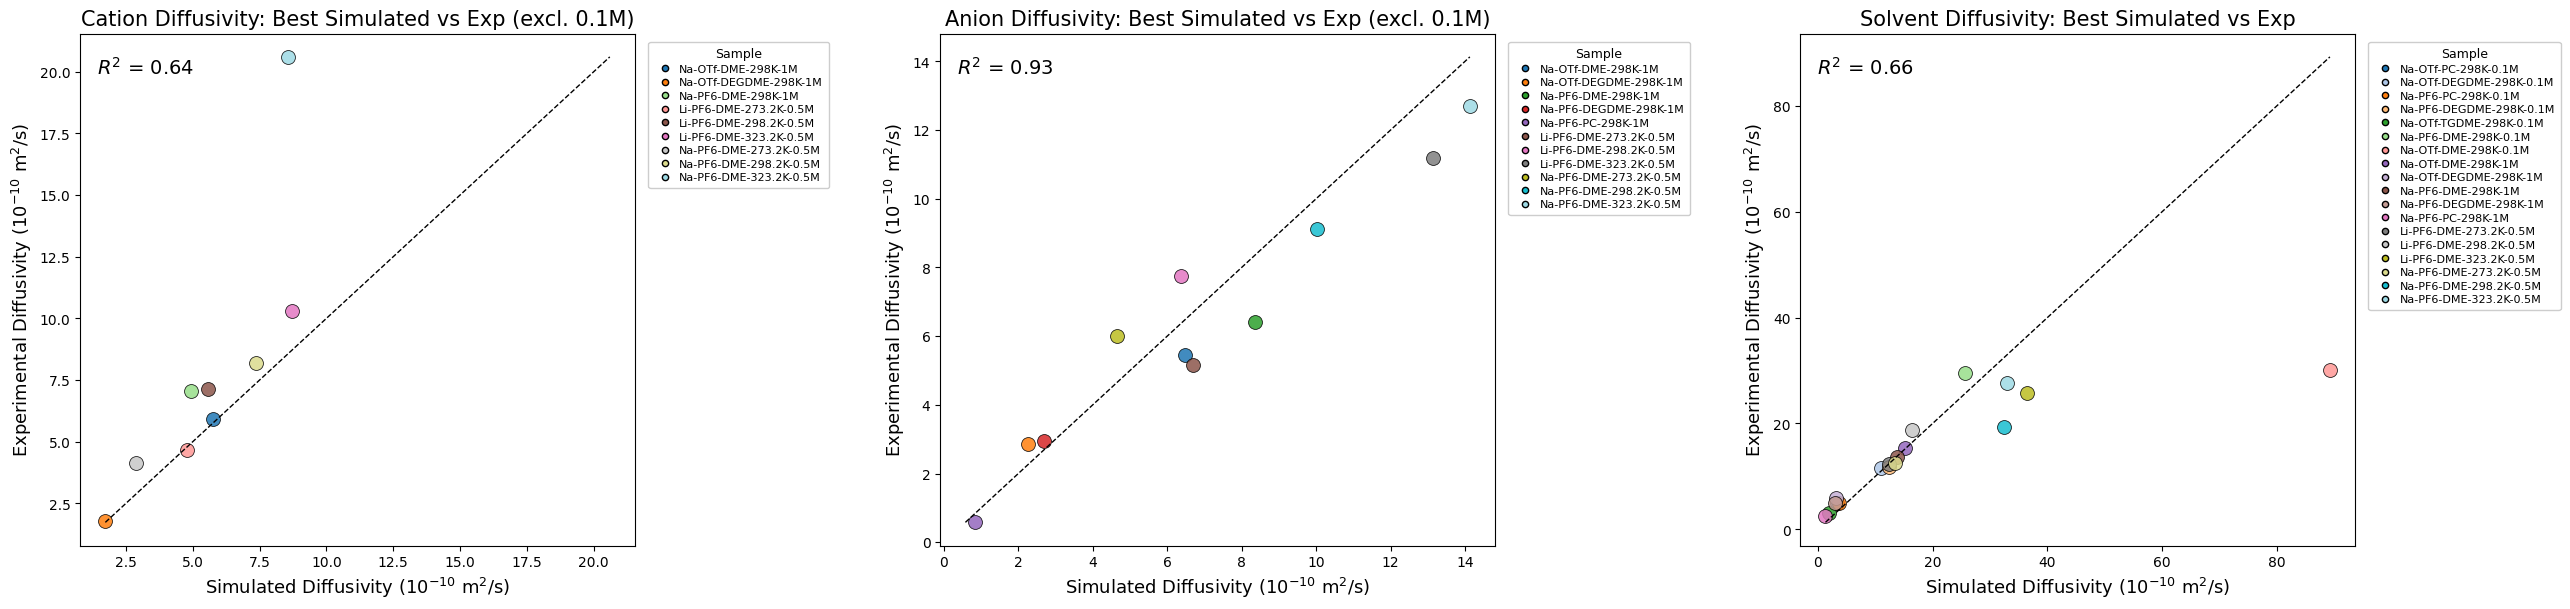

In [5]:
# Helper to create R2 parity plots for each type (normal scale)
def plot_r2_unique_colors(ax, x, y, labels, title, colormap_name='tab20'):
    import matplotlib.cm as cm
    from matplotlib.lines import Line2D

    num_points = len(x)
    # Use recommended API to avoid deprecation warning and ensure future-compatibility.
    try:
        cmap = cm.get_cmap(colormap_name, num_points)
    except Exception:
        # For older matplotlib
        cmap = cm.get_cmap(colormap_name)
    colors = [cmap(i) for i in range(num_points)]

    handle_objs = []
    for i, (xi, yi, label) in enumerate(zip(x, y, labels)):
        handle = ax.scatter([xi], [yi], alpha=0.85, color=[colors[i]], label=str(label), s=100, edgecolor='k', linewidth=0.6)
        handle_objs.append(handle)

    min_val = min(min(x), min(y))
    max_val = max(max(x), max(y))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
    ax.set_xlabel('Simulated Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_ylabel('Experimental Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_title(title, fontsize=15)

    # R^2
    if len(x) > 1:
        correlation_matrix = np.corrcoef(x, y)
        r2 = correlation_matrix[0, 1] ** 2
        ax.text(0.03, 0.92, f"$R^2$ = {r2:.2f}", transform=ax.transAxes, fontsize=14,
                bbox=dict(facecolor='white', alpha=0.54, edgecolor='none'))
    # Set equal aspect for normal scale (auto-scaling axes)
    ax.set_aspect('auto', adjustable='box')

    labels_str = [str(lab) for lab in labels]
    legend_handles = []
    for lab, col in zip(labels_str, colors):
        legend_handles.append(
            Line2D([0],[0], marker='o', color='w', markerfacecolor=col, markeredgecolor='k', markersize=6, label=lab)
        )
    return legend_handles, labels_str

# --------- Pick best simulated value closest to experimental for each sample ---------
diff_types = ['cation', 'anion', 'solvent']

# Simulated value candidate columns for each diffusivity type
sim_candidates = {
    'cation': [
        '353K student cation diffusivity',
        '323K student cation diffusivity',
        '293K student cation diffusivity',
        '323K per salt student cation diffusivity',
    ],
    'anion': [
        '353K student anion diffusivity',
        '323K student anion diffusivity',
        '293K student anion diffusivity',
        '323K per salt student anion diffusivity',
    ],
    'solvent': [
        '353K student solvent diffusivity',
        '323K student solvent diffusivity',
        '293K student solvent diffusivity',
        '323K per salt student solvent diffusivity',
    ]
}

exp_columns = {
    'cation':   'exp student cation diffusivity',
    'anion':    'exp anion diffusivity',
    'solvent':  'exp solvent diffusivity',
}

stability_cols = ['353K_stability', '323K_stability', '293K_stability']

plot_data = []

for dt in diff_types:
    # -------- Mask by type (exclude 0.1M for cation/anion, not for solvent) ---------
    if dt in ['cation', 'anion']:
        exclude = (df['solute concentration'] == '0.1M')
    else:
        exclude = pd.Series([False] * len(df))

    # DISABLING stability mask: consider all rows regardless of stability
    # Only consider rows where all candidate sim values are not null for at least one, and exp is not null
    # For each row, pick the simulated candidate value that's closest to experimental (abs difference)
    best_sim_values = []
    best_exp_values = []
    best_labels = []

    # Mask applied at row level
    for idx, row in df.iterrows():
        if exclude.iloc[idx]:
            continue
        # Disabled: if not stability_mask.iloc[idx]: continue
        exp_val = row[exp_columns[dt]]
        if pd.isnull(exp_val):
            continue

        # For the four possible simulated columns, get only those that are not null
        possible_sim_vals = []
        possible_sim_cols = []
        for col in sim_candidates[dt]:
            val = row[col]
            if not pd.isnull(val):
                possible_sim_vals.append(float(val))
                possible_sim_cols.append(col)

        if len(possible_sim_vals) == 0:
            continue

        # Pick the simulated value closest to the experimental value
        exp_val_float = float(exp_val)
        sim_val_arr = np.array(possible_sim_vals)
        idx_best = np.argmin(np.abs(sim_val_arr - exp_val_float))
        selected_best_sim = sim_val_arr[idx_best]

        # Prepare label
        label = '-'.join([
            str(row['cation']),
            str(row['anion']),
            str(row['solvent']),
            str(row['temperature']),
            str(row['solute concentration'])
        ])

        best_sim_values.append(selected_best_sim)
        best_exp_values.append(exp_val_float)
        best_labels.append(label)

    # Compose plot title, note (excl. 0.1M) for cation/anion
    title = f"{dt.capitalize()} Diffusivity: Best Simulated vs Exp" + ("" if dt == "solvent" else " (excl. 0.1M)")
    plot_data.append((np.array(best_sim_values), np.array(best_exp_values), best_labels, title))

# ----------- Plot all 3 in a 1x3 grid (normal scale) -----------

fig, axes = plt.subplots(1, 3, figsize=(25, 8))
plt.subplots_adjust(left=0.07, right=0.98, bottom=0.23, top=0.87, hspace=0.28, wspace=0.55)

# For each axes, reduce marker size, tighten legend text spacing, and use a compact legend column
for idx, (x, y, labels, title) in enumerate(plot_data):
    ax = axes[idx]
    legend_handles, legend_labels = plot_r2_unique_colors(ax, x, y, labels, title)
    # Place legend further outside right and lower font/spacing for maximal separation
    # legendHandles workaround for matplotlib >=3.7, see: https://github.com/matplotlib/matplotlib/issues/22397
    leg = ax.legend(
        handles=legend_handles, labels=legend_labels,
        loc='upper left', bbox_to_anchor=(1.00, 1.01),
        fontsize=8, framealpha=0.98, borderaxespad=1.2,
        ncol=1, labelspacing=0.32, handletextpad=0.28, borderpad=0.51, markerscale=0.75, title="Sample", title_fontsize=9
    )
    # Remove explicit marker size setting, since matplotlib's Legend object has no legendHandles attribute in recent versions.
    # Instead, pass markersize=6 to Line2D in legend_handles above (already set).

plt.show()

/tmp/ipykernel_709278/2462943188.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap_name, num_points)


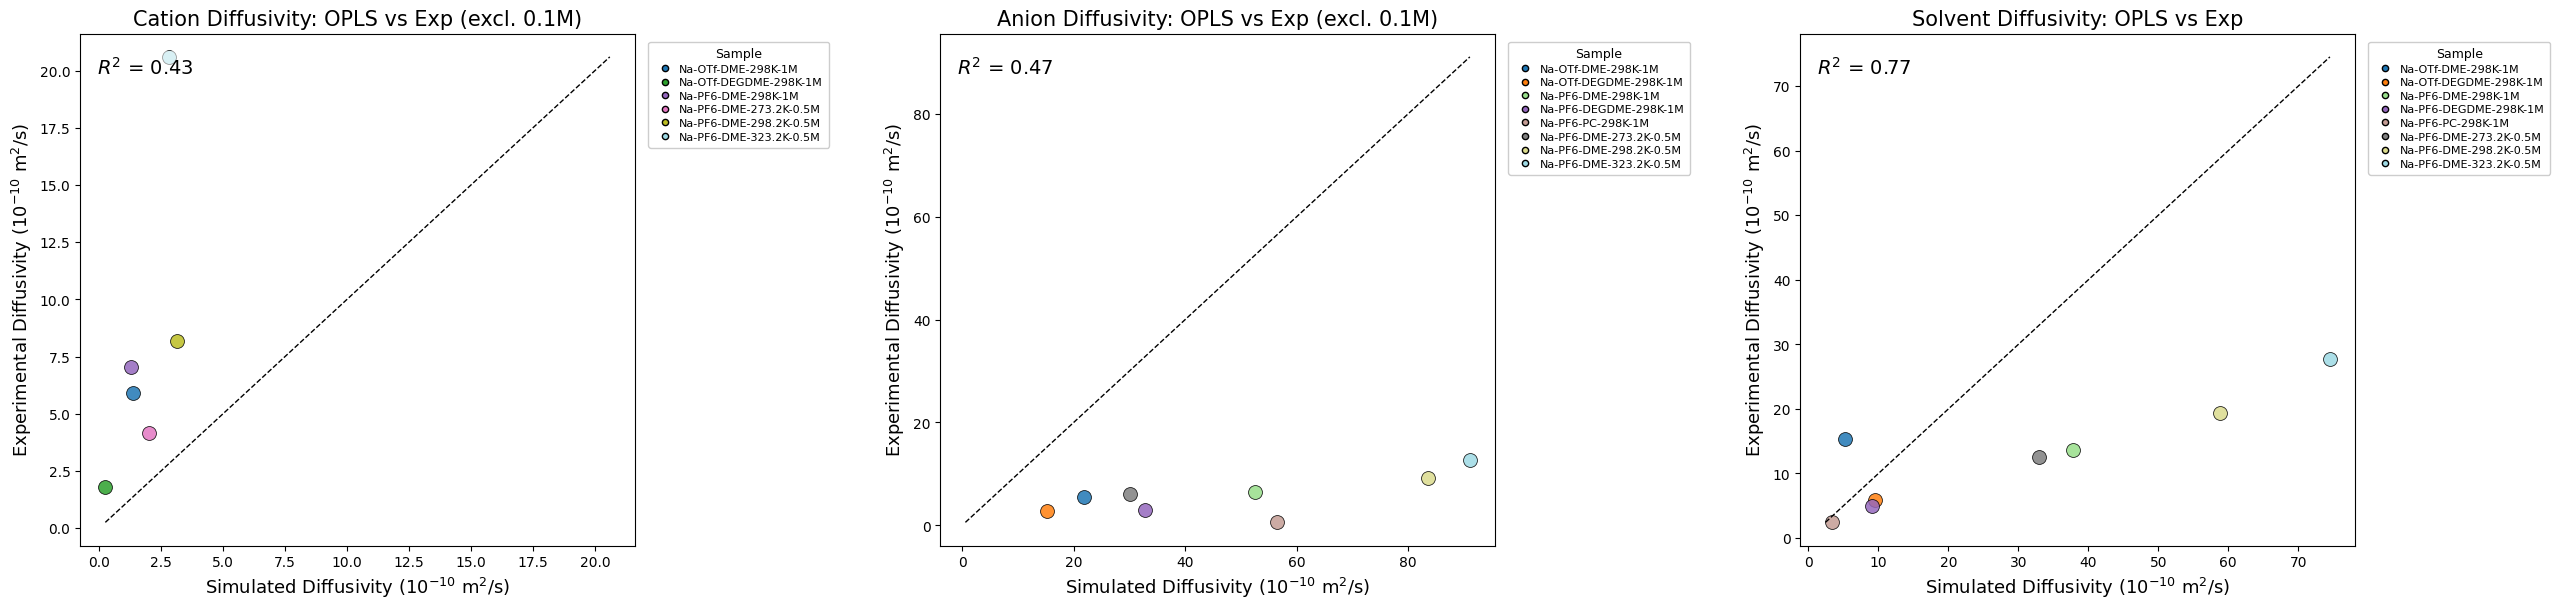

In [ ]:
# Helper to create R2 parity plots for each type (normal scale)
def plot_r2_unique_colors(ax, x, y, labels, title, colormap_name='tab20'):
    import matplotlib.cm as cm
    from matplotlib.lines import Line2D

    num_points = len(x)
    # Use recommended API to avoid deprecation warning and ensure future-compatibility.
    try:
        cmap = cm.get_cmap(colormap_name, num_points)
    except Exception:
        # For older matplotlib
        cmap = cm.get_cmap(colormap_name)
    colors = [cmap(i) for i in range(num_points)]

    handle_objs = []
    for i, (xi, yi, label) in enumerate(zip(x, y, labels)):
        handle = ax.scatter([xi], [yi], alpha=0.85, color=[colors[i]], label=str(label), s=100, edgecolor='k', linewidth=0.6)
        handle_objs.append(handle)

    min_val = min(min(x), min(y))
    max_val = max(max(x), max(y))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
    ax.set_xlabel('Simulated Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_ylabel('Experimental Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_title(title, fontsize=15)

    # R^2
    if len(x) > 1:
        correlation_matrix = np.corrcoef(x, y)
        r2 = correlation_matrix[0, 1] ** 2
        ax.text(0.03, 0.92, f"$R^2$ = {r2:.2f}", transform=ax.transAxes, fontsize=14,
                bbox=dict(facecolor='white', alpha=0.54, edgecolor='none'))
    # Set equal aspect for normal scale (auto-scaling axes)
    ax.set_aspect('auto', adjustable='box')

    labels_str = [str(lab) for lab in labels]
    legend_handles = []
    for lab, col in zip(labels_str, colors):
        legend_handles.append(
            Line2D([0],[0], marker='o', color='w', markerfacecolor=col, markeredgecolor='k', markersize=6, label=lab)
        )
    return legend_handles, labels_str

# --------- Plot OPLS vs Experimental for cation, anion, and solvent (Normal Scale) ---------
diff_types = ['cation', 'anion', 'solvent']

opls_columns = {
    'cation':   'OPLS cation diffusivity',
    'anion':    'OPLS anion diffusivity',
    'solvent':  'OPLS student solvent diffusivity',
}

exp_columns = {
    'cation':   'exp student cation diffusivity',
    'anion':    'exp anion diffusivity',
    'solvent':  'exp solvent diffusivity',
}

plot_data = []

for dt in diff_types:
    # Exclude 0.1M for cation/anion, not for solvent
    if dt in ['cation', 'anion']:
        exclude = (df['solute concentration'] == '0.1M')
    else:
        exclude = pd.Series([False] * len(df))

    sim_values = []
    exp_values = []
    labels = []
    for idx, row in df.iterrows():
        if exclude.iloc[idx]:
            continue
        opls_val = row[opls_columns[dt]]
        exp_val = row[exp_columns[dt]]
        if pd.isnull(opls_val) or pd.isnull(exp_val):
            continue
        sim_values.append(float(opls_val))
        exp_values.append(float(exp_val))
        label = '-'.join([
            str(row['cation']),
            str(row['anion']),
            str(row['solvent']),
            str(row['temperature']),
            str(row['solute concentration'])
        ])
        labels.append(label)
    # Compose plot title, note (excl. 0.1M) for cation/anion
    title = f"{dt.capitalize()} Diffusivity: OPLS vs Exp" + ("" if dt == "solvent" else " (excl. 0.1M)")
    plot_data.append((np.array(sim_values), np.array(exp_values), labels, title))

# ----------- Plot all 3 in a 1x3 grid (Normal Linear Scale) -----------
# Plot is always normal/linear scale, not log scale
fig, axes = plt.subplots(1, 3, figsize=(25, 8))
plt.subplots_adjust(left=0.07, right=0.98, bottom=0.23, top=0.87, hspace=0.28, wspace=0.55)

for idx, (x, y, labels, title) in enumerate(plot_data):
    ax = axes[idx]
    # Ensure axes are always linear (not log scale)
    legend_handles, legend_labels = plot_r2_unique_colors(ax, x, y, labels, title)
    ax.set_xscale('linear')
    ax.set_yscale('linear')
    ax.legend(
        handles=legend_handles, labels=legend_labels,
        loc='upper left', bbox_to_anchor=(1.00, 1.01),
        fontsize=8, framealpha=0.98, borderaxespad=1.2,
        ncol=1, labelspacing=0.32, handletextpad=0.28, borderpad=0.51, markerscale=0.75, title="Sample", title_fontsize=9
    )

plt.show()

/tmp/ipykernel_709278/4104325473.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap_name, num_points)


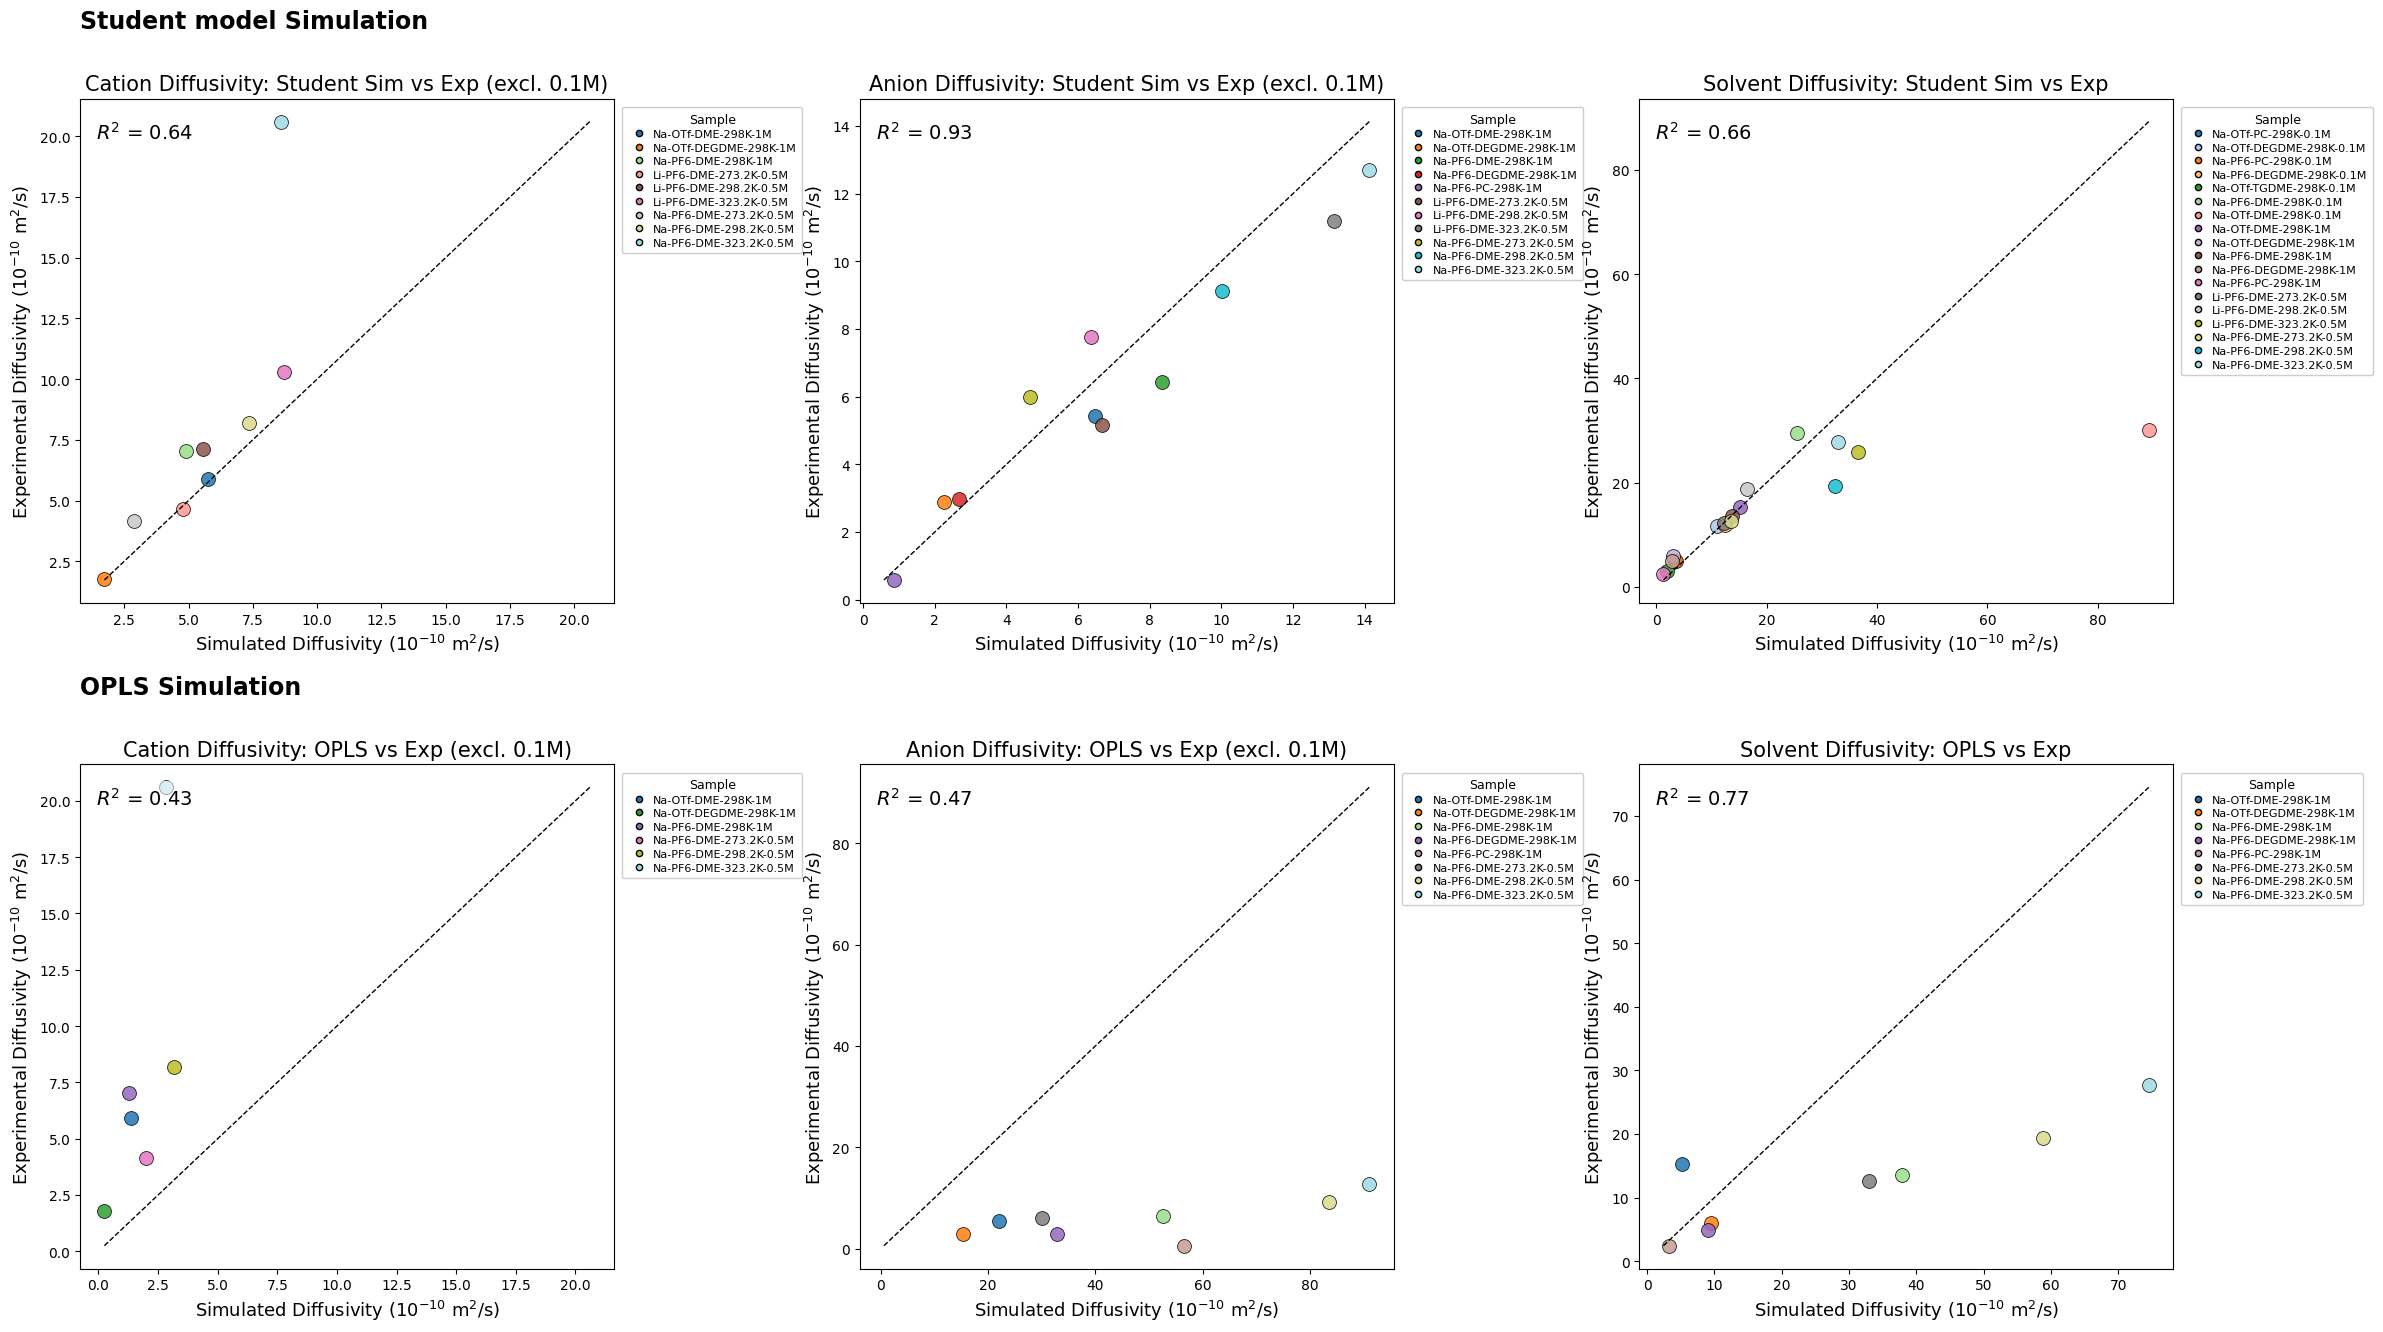

In [ ]:
# Helper to create R2 parity plots for each type (normal scale)
def plot_r2_unique_colors(ax, x, y, labels, title, colormap_name='tab20'):
    import matplotlib.cm as cm
    from matplotlib.lines import Line2D

    num_points = len(x)
    # Use recommended API to avoid deprecation warning and ensure future-compatibility.
    try:
        cmap = cm.get_cmap(colormap_name, num_points)
    except Exception:
        # For older matplotlib
        cmap = cm.get_cmap(colormap_name)
    colors = [cmap(i) for i in range(num_points)]

    handle_objs = []
    for i, (xi, yi, label) in enumerate(zip(x, y, labels)):
        handle = ax.scatter([xi], [yi], alpha=0.85, color=[colors[i]], label=str(label), s=100, edgecolor='k', linewidth=0.6)
        handle_objs.append(handle)

    min_val = min(min(x), min(y))
    max_val = max(max(x), max(y))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
    ax.set_xlabel('Simulated Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_ylabel('Experimental Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_title(title, fontsize=15)

    # R^2
    if len(x) > 1:
        correlation_matrix = np.corrcoef(x, y)
        r2 = correlation_matrix[0, 1] ** 2
        ax.text(0.03, 0.92, f"$R^2$ = {r2:.2f}", transform=ax.transAxes, fontsize=14,
                bbox=dict(facecolor='white', alpha=0.54, edgecolor='none'))
    # Set equal aspect for normal scale (auto-scaling axes)
    ax.set_aspect('auto', adjustable='box')

    labels_str = [str(lab) for lab in labels]
    legend_handles = []
    for lab, col in zip(labels_str, colors):
        legend_handles.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=col, markeredgecolor='k', markersize=6, label=lab)
        )
    return legend_handles, labels_str

# --------- 2,3 comparison plot: [best temp vs exp] and [opls vs exp] for each diff type ---------
diff_types = ['cation', 'anion', 'solvent']

sim_candidates = {
    'cation': [
        '353K student cation diffusivity',
        '323K student cation diffusivity',
        '293K student cation diffusivity',
        '323K per salt student cation diffusivity',
    ],
    'anion': [
        '353K student anion diffusivity',
        '323K student anion diffusivity',
        '293K student anion diffusivity',
        '323K per salt student anion diffusivity',
    ],
    'solvent': [
        '353K student solvent diffusivity',
        '323K student solvent diffusivity',
        '293K student solvent diffusivity',
        '323K per salt student solvent diffusivity',
    ]
}

exp_columns = {
    'cation':   'exp student cation diffusivity',
    'anion':    'exp anion diffusivity',
    'solvent':  'exp solvent diffusivity',
}

opls_columns = {
    'cation':   'OPLS cation diffusivity',
    'anion':    'OPLS anion diffusivity',
    'solvent':  'OPLS student solvent diffusivity',
}

# For each type, gather two sets of data: [best temp sim - exp] (all w/ exp), [opls - exp]
best_sim_plotdata = []
opls_plotdata = []

for dt in diff_types:
    # Exclude 0.1M for cation/anion, not for solvent
    if dt in ['cation', 'anion']:
        exclude = (df['solute concentration'] == '0.1M')
    else:
        exclude = pd.Series([False] * len(df))

    # ------------------ OPLS vs exp ------------------
    sim_values = []
    exp_values = []
    labels = []
    for idx, row in df.iterrows():
        if exclude.iloc[idx]:
            continue
        opls_val = row[opls_columns[dt]]
        exp_val = row[exp_columns[dt]]
        if pd.isnull(opls_val) or pd.isnull(exp_val):
            continue
        sim_values.append(float(opls_val))
        exp_values.append(float(exp_val))
        label = '-'.join([
            str(row['cation']),
            str(row['anion']),
            str(row['solvent']),
            str(row['temperature']),
            str(row['solute concentration'])
        ])
        labels.append(label)
    title = f"{dt.capitalize()} Diffusivity: OPLS vs Exp" + ("" if dt == "solvent" else " (excl. 0.1M)")
    opls_plotdata.append((np.array(sim_values), np.array(exp_values), labels, title))

    # ---------------- Best sim (from temps) vs exp; INCLUDE ALL with exp (ignore OPLS presence) ------------------
    best_sim_values = []
    best_exp_values = []
    best_labels = []
    for idx, row in df.iterrows():
        if exclude.iloc[idx]:
            continue
        exp_val = row[exp_columns[dt]]
        if pd.isnull(exp_val):
            continue
        # Gather all possible simulation values (from different temps)
        possible_sim_vals = []
        for col in sim_candidates[dt]:
            val = row[col]
            if not pd.isnull(val):
                possible_sim_vals.append(float(val))
        if len(possible_sim_vals) == 0:
            continue
        exp_val_float = float(exp_val)
        sim_val_arr = np.array(possible_sim_vals)
        idx_best = np.argmin(np.abs(sim_val_arr - exp_val_float))
        selected_best_sim = sim_val_arr[idx_best]
        label = '-'.join([
            str(row['cation']),
            str(row['anion']),
            str(row['solvent']),
            str(row['temperature']),
            str(row['solute concentration'])
        ])
        best_sim_values.append(selected_best_sim)
        best_exp_values.append(exp_val_float)
        best_labels.append(label)
    title = f"{dt.capitalize()} Diffusivity: Student Sim vs Exp" + ("" if dt == "solvent" else " (excl. 0.1M)")
    best_sim_plotdata.append((np.array(best_sim_values), np.array(best_exp_values), best_labels, title))

# ----------- Plot in a 2 x 3 grid (best temp sim vs exp and OPLS vs exp for each type) -----------
fig, axes = plt.subplots(2, 3, figsize=(23, 15))
plt.subplots_adjust(left=0.07, right=0.98, bottom=0.11, top=0.89, hspace=0.32, wspace=0.46)

for row, pdata_group in enumerate([best_sim_plotdata, opls_plotdata]):
    for col, (x, y, labels, title) in enumerate(pdata_group):
        ax = axes[row, col]
        legend_handles, legend_labels = plot_r2_unique_colors(ax, x, y, labels, title)
        ax.set_xscale('linear')
        ax.set_yscale('linear')
        ax.legend(
            handles=legend_handles, labels=legend_labels,
            loc='upper left', bbox_to_anchor=(0.99, 1.01),
            fontsize=8, framealpha=0.98, borderaxespad=1.2,
            ncol=1, labelspacing=0.32, handletextpad=0.28, borderpad=0.51, markerscale=0.75, title="Sample", title_fontsize=9
        )

# Add row labels
axes[0,0].annotate("Student model Simulation", xy=(0, 1.14), xycoords="axes fraction", fontsize=17, fontweight='bold')
axes[1,0].annotate("OPLS Simulation", xy=(0, 1.14), xycoords="axes fraction", fontsize=17, fontweight='bold')

plt.show()


/tmp/ipykernel_709278/4056611728.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap_name, num_points)


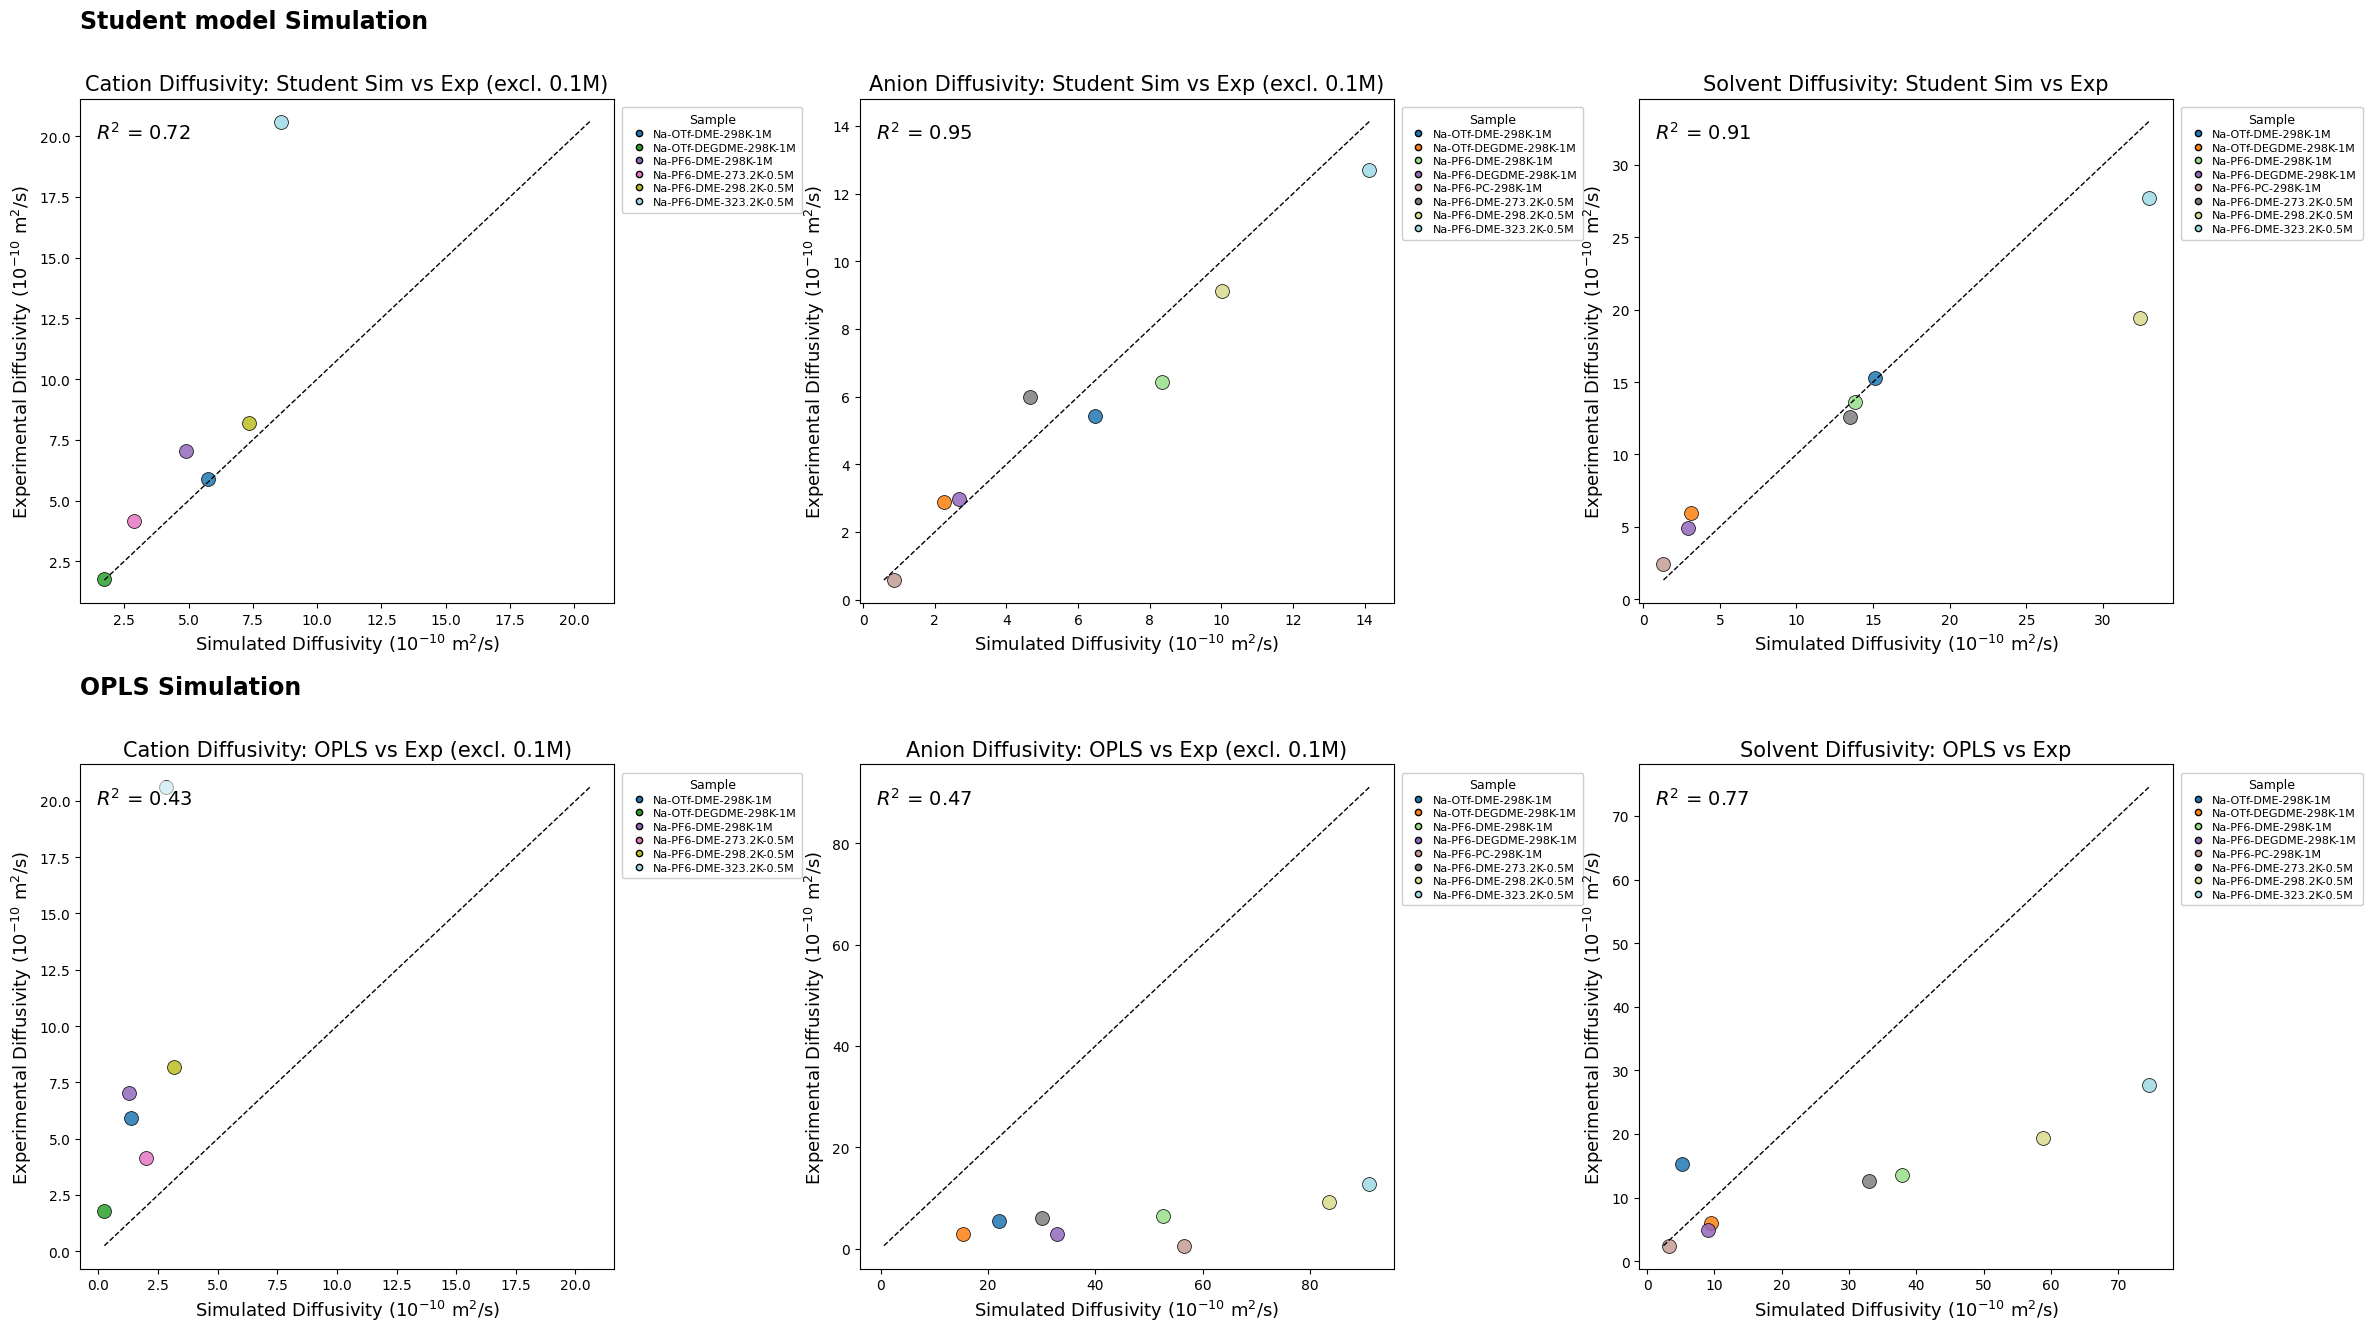

In [ ]:
# Helper to create R2 parity plots for each type (normal scale)
def plot_r2_unique_colors(ax, x, y, labels, title, colormap_name='tab20'):
    import matplotlib.cm as cm
    from matplotlib.lines import Line2D

    num_points = len(x)
    # Use recommended API to avoid deprecation warning and ensure future-compatibility.
    try:
        cmap = cm.get_cmap(colormap_name, num_points)
    except Exception:
        # For older matplotlib
        cmap = cm.get_cmap(colormap_name)
    colors = [cmap(i) for i in range(num_points)]

    handle_objs = []
    for i, (xi, yi, label) in enumerate(zip(x, y, labels)):
        handle = ax.scatter([xi], [yi], alpha=0.85, color=[colors[i]], label=str(label), s=100, edgecolor='k', linewidth=0.6)
        handle_objs.append(handle)

    min_val = min(min(x), min(y))
    max_val = max(max(x), max(y))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
    ax.set_xlabel('Simulated Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_ylabel('Experimental Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_title(title, fontsize=15)

    # R^2
    if len(x) > 1:
        correlation_matrix = np.corrcoef(x, y)
        r2 = correlation_matrix[0, 1] ** 2
        ax.text(0.03, 0.92, f"$R^2$ = {r2:.2f}", transform=ax.transAxes, fontsize=14,
                bbox=dict(facecolor='white', alpha=0.54, edgecolor='none'))
    # Set equal aspect for normal scale (auto-scaling axes)
    ax.set_aspect('auto', adjustable='box')

    labels_str = [str(lab) for lab in labels]
    legend_handles = []
    for lab, col in zip(labels_str, colors):
        legend_handles.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=col, markeredgecolor='k', markersize=6, label=lab)
        )
    return legend_handles, labels_str

# --------- 2,3 comparison plot: [best temp vs exp] and [opls vs exp] for each diff type ---------
diff_types = ['cation', 'anion', 'solvent']

sim_candidates = {
    'cation': [
        '353K student cation diffusivity',
        '323K student cation diffusivity',
        '293K student cation diffusivity',
        '323K per salt student cation diffusivity',
    ],
    'anion': [
        '353K student anion diffusivity',
        '323K student anion diffusivity',
        '293K student anion diffusivity',
        '323K per salt student anion diffusivity',
    ],
    'solvent': [
        '353K student solvent diffusivity',
        '323K student solvent diffusivity',
        '293K student solvent diffusivity',
        '323K per salt student solvent diffusivity',
    ]
}

exp_columns = {
    'cation':   'exp student cation diffusivity',
    'anion':    'exp anion diffusivity',
    'solvent':  'exp solvent diffusivity',
}

opls_columns = {
    'cation':   'OPLS cation diffusivity',
    'anion':    'OPLS anion diffusivity',
    'solvent':  'OPLS student solvent diffusivity',
}

# For each type, gather two sets of data: [best temp sim - exp] (only for systems with OPLS value), [opls - exp]
best_sim_plotdata = []
opls_plotdata = []

for dt in diff_types:
    # Exclude 0.1M for cation/anion, not for solvent
    if dt in ['cation', 'anion']:
        exclude = (df['solute concentration'] == '0.1M')
    else:
        exclude = pd.Series([False] * len(df))

    # ------------------ OPLS vs exp ------------------
    sim_values = []
    exp_values = []
    labels = []
    for idx, row in df.iterrows():
        if exclude.iloc[idx]:
            continue
        opls_val = row[opls_columns[dt]]
        exp_val = row[exp_columns[dt]]
        if pd.isnull(opls_val) or pd.isnull(exp_val):
            continue
        sim_values.append(float(opls_val))
        exp_values.append(float(exp_val))
        label = '-'.join([
            str(row['cation']),
            str(row['anion']),
            str(row['solvent']),
            str(row['temperature']),
            str(row['solute concentration'])
        ])
        labels.append(label)
    title = f"{dt.capitalize()} Diffusivity: OPLS vs Exp" + ("" if dt == "solvent" else " (excl. 0.1M)")
    opls_plotdata.append((np.array(sim_values), np.array(exp_values), labels, title))

    # ---------------- Best sim (from temps) vs exp; ONLY for systems with OPLS value ------------------
    best_sim_values = []
    best_exp_values = []
    best_labels = []
    for idx, row in df.iterrows():
        if exclude.iloc[idx]:
            continue
        # Require both exp and OPLS present
        exp_val = row[exp_columns[dt]]
        opls_val = row[opls_columns[dt]]
        if pd.isnull(exp_val) or pd.isnull(opls_val):
            continue
        # Gather all possible simulation values (from different temps)
        possible_sim_vals = []
        for col in sim_candidates[dt]:
            val = row[col]
            if not pd.isnull(val):
                possible_sim_vals.append(float(val))
        if len(possible_sim_vals) == 0:
            continue
        exp_val_float = float(exp_val)
        sim_val_arr = np.array(possible_sim_vals)
        idx_best = np.argmin(np.abs(sim_val_arr - exp_val_float))
        selected_best_sim = sim_val_arr[idx_best]
        label = '-'.join([
            str(row['cation']),
            str(row['anion']),
            str(row['solvent']),
            str(row['temperature']),
            str(row['solute concentration'])
        ])
        best_sim_values.append(selected_best_sim)
        best_exp_values.append(exp_val_float)
        best_labels.append(label)
    title = f"{dt.capitalize()} Diffusivity: Student Sim vs Exp" + ("" if dt == "solvent" else " (excl. 0.1M)")
    best_sim_plotdata.append((np.array(best_sim_values), np.array(best_exp_values), best_labels, title))

# ----------- Plot in a 2 x 3 grid (best temp sim vs exp and OPLS vs exp for each type) -----------
fig, axes = plt.subplots(2, 3, figsize=(23, 15))
plt.subplots_adjust(left=0.07, right=0.98, bottom=0.11, top=0.89, hspace=0.32, wspace=0.46)

for row, pdata_group in enumerate([best_sim_plotdata, opls_plotdata]):
    for col, (x, y, labels, title) in enumerate(pdata_group):
        ax = axes[row, col]
        legend_handles, legend_labels = plot_r2_unique_colors(ax, x, y, labels, title)
        ax.set_xscale('linear')
        ax.set_yscale('linear')
        ax.legend(
            handles=legend_handles, labels=legend_labels,
            loc='upper left', bbox_to_anchor=(0.99, 1.01),
            fontsize=8, framealpha=0.98, borderaxespad=1.2,
            ncol=1, labelspacing=0.32, handletextpad=0.28, borderpad=0.51, markerscale=0.75, title="Sample", title_fontsize=9
        )

# Add row labels
axes[0,0].annotate("Student model Simulation", xy=(0, 1.14), xycoords="axes fraction", fontsize=17, fontweight='bold')
axes[1,0].annotate("OPLS Simulation", xy=(0, 1.14), xycoords="axes fraction", fontsize=17, fontweight='bold')

plt.show()
